# Model Calibration

A model is **well-calibrated** if its predicted probabilities match empirical frequencies — when it says 80%, it should be right 80% of the time. This matters enormously in high-stakes applications like medical diagnosis, credit scoring, and weather forecasting.

## What You'll Learn
- What calibration is and why it matters
- Reliability diagrams (calibration curves) from scratch
- Expected Calibration Error (ECE) and Maximum Calibration Error (MCE)
- Why common models are miscalibrated (SVMs, boosting, neural nets)
- Platt Scaling — post-hoc calibration from scratch
- Isotonic Regression calibration
- Temperature Scaling for neural networks
- sklearn CalibratedClassifierCV

## When Calibration Matters
- **Medical**: 60% cancer risk needs to mean 60%, not just "more likely than 50%"
- **Finance**: loan default probabilities feed directly into pricing models
- **Ensemble decisions**: only meaningful when probabilities are comparable
- **Decision thresholds**: knowing P(Y=1)=0.12 vs 0.48 changes the decision even if both round to "positive"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from scipy.optimize import minimize_scalar
from scipy.special import expit  # sigmoid
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK')

Imports OK


In [2]:
# Generate a classification dataset
X, y = make_classification(n_samples=5000, n_features=20, n_informative=10,
                            n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance: {y_train.mean():.2f} positive')

Train: (3500, 20), Test: (1500, 20)
Class balance: 0.50 positive


---
## 1. Calibration Curve (Reliability Diagram) — From Scratch

**Algorithm:**
1. Get predicted probabilities $\hat{p}_i$
2. Bin them into $B$ equal-width bins $[0, 1/B), [1/B, 2/B), \ldots$
3. For each bin: compute mean predicted probability and mean actual label
4. Plot bin centers vs actual frequency — a perfectly calibrated model lies on the diagonal

**Expected Calibration Error (ECE):**
$$\text{ECE} = \sum_{b=1}^B \frac{|B_b|}{n} \left|\overline{y}_{B_b} - \overline{\hat{p}}_{B_b}\right|$$

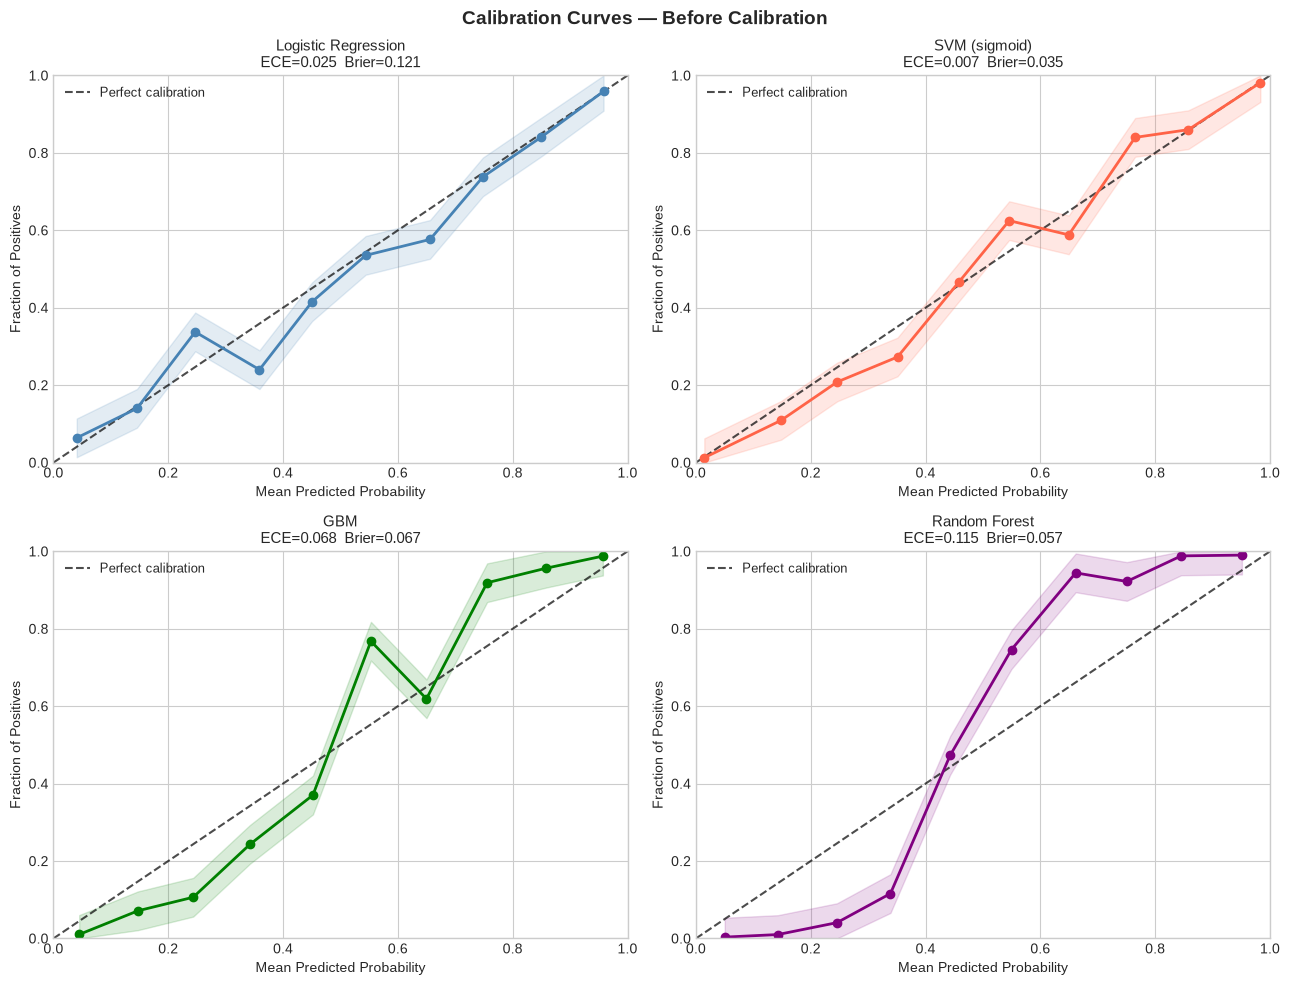


Calibration Summary:
  Logistic Regression      : ECE=0.0253  MCE=0.1189  Brier=0.1210
  SVM (sigmoid)            : ECE=0.0072  MCE=0.0793  Brier=0.0346
  GBM                      : ECE=0.0676  MCE=0.2148  Brier=0.0672
  Random Forest            : ECE=0.1152  MCE=0.2829  Brier=0.0573


In [3]:
def calibration_analysis(y_true, y_prob, n_bins=10, label='Model'):
    """Compute calibration curve and ECE from scratch."""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_means_pred = []
    bin_means_actual = []
    bin_counts = []

    for low, high in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= low) & (y_prob < high)
        if mask.sum() > 0:
            bin_means_pred.append(y_prob[mask].mean())
            bin_means_actual.append(y_true[mask].mean())
            bin_counts.append(mask.sum())

    bin_means_pred = np.array(bin_means_pred)
    bin_means_actual = np.array(bin_means_actual)
    bin_counts = np.array(bin_counts)

    # ECE: weighted average calibration error
    ece = np.sum(bin_counts * np.abs(bin_means_pred - bin_means_actual)) / len(y_true)
    # MCE: worst single bin
    mce = np.max(np.abs(bin_means_pred - bin_means_actual))
    # Brier score
    bs = np.mean((y_prob - y_true)**2)

    return {
        'pred': bin_means_pred, 'actual': bin_means_actual,
        'counts': bin_counts, 'ece': ece, 'mce': mce, 'brier': bs,
        'label': label
    }

# Train several models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM (sigmoid)': SVC(probability=True, random_state=42),
    'GBM': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = calibration_analysis(y_test, y_prob, label=name)

# Plot calibration curves
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
colors = ['steelblue', 'tomato', 'green', 'purple']
for ax, (name, res), col in zip(axes.flat, results.items(), colors):
    ax.plot([0,1], [0,1], 'k--', linewidth=1.5, label='Perfect calibration', alpha=0.7)
    ax.plot(res['pred'], res['actual'], 'o-', color=col, linewidth=2, markersize=6)
    ax.fill_between(res['pred'],
                    np.maximum(res['actual']-0.05, 0),
                    np.minimum(res['actual']+0.05, 1), alpha=0.15, color=col)
    ax.set_title(f'{name}\nECE={res["ece"]:.3f}  Brier={res["brier"]:.3f}', fontsize=11)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

plt.suptitle('Calibration Curves — Before Calibration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration_before.png', dpi=80, bbox_inches='tight')
plt.show()

print('\nCalibration Summary:')
for name, res in results.items():
    print(f'  {name:25s}: ECE={res["ece"]:.4f}  MCE={res["mce"]:.4f}  Brier={res["brier"]:.4f}')

---
## 2. Platt Scaling — From Scratch

Platt scaling fits a sigmoid function on top of model scores:

$$P(y=1 \mid f(x)) = \sigma(Af(x) + B) = \frac{1}{1 + e^{-(Af(x)+B)}}$$

Parameters $A$ and $B$ are fit by minimizing log-loss on a held-out calibration set. This is equivalent to logistic regression with the raw scores as the single feature.

**Why not train on the training set?** The model has already overfit to the training data, so scores there are overly extreme. We need a separate calibration set.

In [4]:
class PlattScaling:
    """Post-hoc probability calibration using logistic regression on raw scores."""
    def __init__(self):
        self.calibrator = LogisticRegression(C=1.0)

    def fit(self, raw_scores, y_true):
        self.calibrator.fit(raw_scores.reshape(-1, 1), y_true)
        return self

    def predict_proba(self, raw_scores):
        return self.calibrator.predict_proba(raw_scores.reshape(-1, 1))[:, 1]

    @property
    def A(self):
        return self.calibrator.coef_[0][0]

    @property
    def B(self):
        return self.calibrator.intercept_[0]


# Use GBM (typically overconfident) as the base model
gbm = GradientBoostingClassifier(n_estimators=100, random_state=42)
gbm.fit(X_train, y_train)

# Split test set into calibration and final eval
X_cal, X_eval, y_cal, y_eval = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

# Calibration scores (raw GBM probabilities on calibration set)
cal_scores = gbm.predict_proba(X_cal)[:, 1]
eval_scores_raw = gbm.predict_proba(X_eval)[:, 1]

# Fit Platt scaling
platt = PlattScaling().fit(cal_scores, y_cal)
eval_scores_platt = platt.predict_proba(eval_scores_raw)

print(f'Platt A={platt.A:.4f}, B={platt.B:.4f}')

raw_stats = calibration_analysis(y_eval, eval_scores_raw, label='GBM Raw')
platt_stats = calibration_analysis(y_eval, eval_scores_platt, label='GBM + Platt')

print(f'\nGBM Raw:       ECE={raw_stats["ece"]:.4f}  Brier={raw_stats["brier"]:.4f}')
print(f'GBM + Platt:   ECE={platt_stats["ece"]:.4f}  Brier={platt_stats["brier"]:.4f}')

Platt A=7.0582, B=-3.5375

GBM Raw:       ECE=0.0639  Brier=0.0702
GBM + Platt:   ECE=0.0395  Brier=0.0665


---
## 3. Isotonic Regression Calibration

Isotonic regression fits a **non-decreasing step function** to the scores. It's more flexible than Platt scaling but needs more data and can overfit on small calibration sets.

Formally: find $\hat{f}$ minimizing $\sum_i (y_i - \hat{f}(\hat{p}_i))^2$ subject to $\hat{f}$ being non-decreasing.

GBM Raw:        ECE=0.0639  Brier=0.0702
GBM + Platt:    ECE=0.0395  Brier=0.0665
GBM + Isotonic: ECE=0.0239  Brier=0.0665


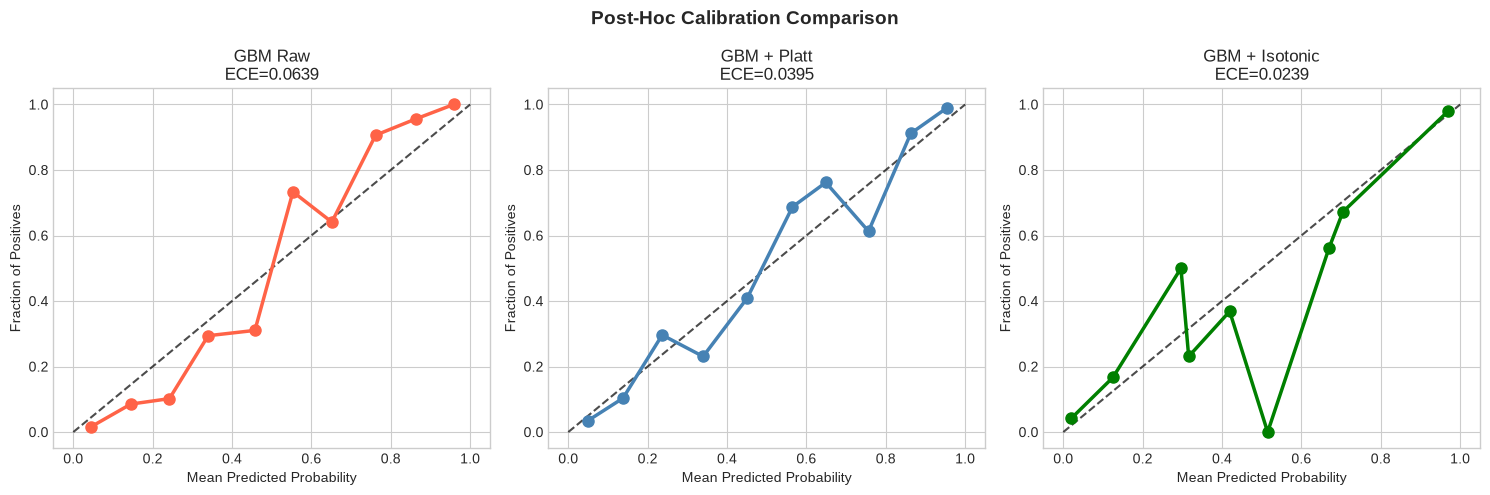

In [5]:
from sklearn.isotonic import IsotonicRegression

class IsotonicCalibration:
    def __init__(self):
        self.iso = IsotonicRegression(out_of_bounds='clip')

    def fit(self, raw_scores, y_true):
        self.iso.fit(raw_scores, y_true)
        return self

    def predict_proba(self, raw_scores):
        return self.iso.predict(raw_scores)

iso_cal = IsotonicCalibration().fit(cal_scores, y_cal)
eval_scores_iso = iso_cal.predict_proba(eval_scores_raw)

iso_stats = calibration_analysis(y_eval, eval_scores_iso, label='GBM + Isotonic')
print(f'GBM Raw:        ECE={raw_stats["ece"]:.4f}  Brier={raw_stats["brier"]:.4f}')
print(f'GBM + Platt:    ECE={platt_stats["ece"]:.4f}  Brier={platt_stats["brier"]:.4f}')
print(f'GBM + Isotonic: ECE={iso_stats["ece"]:.4f}  Brier={iso_stats["brier"]:.4f}')

# Compare calibration curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, stats, color in zip(axes,
                             [raw_stats, platt_stats, iso_stats],
                             ['tomato', 'steelblue', 'green']):
    ax.plot([0,1], [0,1], 'k--', linewidth=1.5, alpha=0.7)
    ax.plot(stats['pred'], stats['actual'], 'o-', color=color, linewidth=2.5, markersize=8)
    ax.set_title(f'{stats["label"]}\nECE={stats["ece"]:.4f}', fontsize=12)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)

plt.suptitle('Post-Hoc Calibration Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('calibration_comparison.png', dpi=80, bbox_inches='tight')
plt.show()

---
## 4. Temperature Scaling — Neural Network Calibration

Modern neural networks are often **overconfident** — they output very high logits. Temperature scaling divides all logits by a single parameter $T > 0$:

$$P(y=k \mid x) = \text{softmax}\left(\frac{\mathbf{z}}{T}\right)_k$$

- $T > 1$: softens distribution → reduces overconfidence
- $T < 1$: sharpens distribution → increases confidence
- $T = 1$: no change

$T$ is found by minimizing NLL on a validation set (1D optimization).

Optimal temperature: T = 2.7151
Before: ECE=0.3023  Brier=0.2124
After:  ECE=0.2438  Brier=0.1754


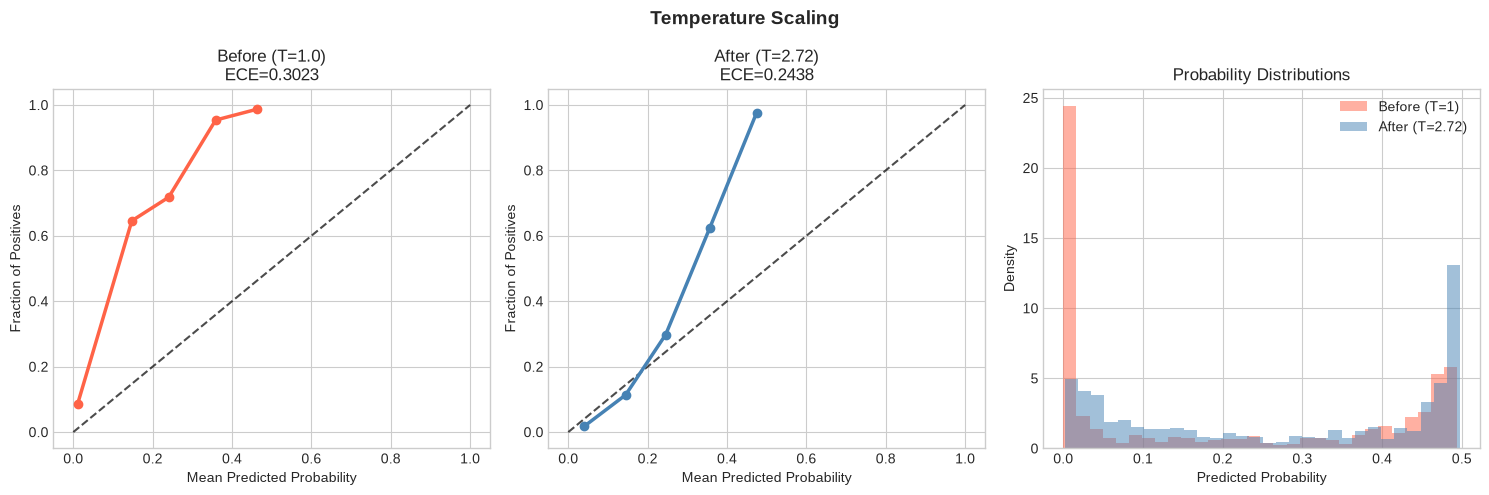

In [6]:
def temperature_scaling_optimize(logits, y_true):
    """Find optimal temperature T to minimize NLL."""
    def nll(T):
        scaled = logits / T
        # Sigmoid for binary case
        probs = expit(scaled)
        probs = np.clip(probs, 1e-7, 1-1e-7)
        return -np.mean(y_true * np.log(probs) + (1-y_true) * np.log(1-probs))

    result = minimize_scalar(nll, bounds=(0.1, 10.0), method='bounded')
    return result.x


# Simulate logits from an overconfident neural net (large magnitudes)
gbm_logits_cal = np.log(np.clip(cal_scores, 1e-7, 1-1e-7))
gbm_logits_eval = np.log(np.clip(eval_scores_raw, 1e-7, 1-1e-7))

# Make the logits more extreme to simulate overconfident NN
overconf_logits_cal = gbm_logits_cal * 3.0
overconf_logits_eval = gbm_logits_eval * 3.0

# Before temperature scaling
probs_before = expit(overconf_logits_eval)

# Find optimal temperature
T_opt = temperature_scaling_optimize(overconf_logits_cal, y_cal)
probs_after = expit(overconf_logits_eval / T_opt)

before_stats = calibration_analysis(y_eval, probs_before, label='Before (T=1.0)')
after_stats = calibration_analysis(y_eval, probs_after, label=f'After (T={T_opt:.2f})')

print(f'Optimal temperature: T = {T_opt:.4f}')
print(f'Before: ECE={before_stats["ece"]:.4f}  Brier={before_stats["brier"]:.4f}')
print(f'After:  ECE={after_stats["ece"]:.4f}  Brier={after_stats["brier"]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Calibration curves
for ax, st, color in [(axes[0], before_stats, 'tomato'), (axes[1], after_stats, 'steelblue')]:
    ax.plot([0,1],[0,1],'k--', alpha=0.7)
    ax.plot(st['pred'], st['actual'], 'o-', color=color, linewidth=2.5)
    ax.set_title(f'{st["label"]}\nECE={st["ece"]:.4f}', fontsize=12)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')

# Histogram of predicted probabilities before/after
axes[2].hist(probs_before, bins=30, alpha=0.5, color='tomato', label=f'Before (T=1)', density=True)
axes[2].hist(probs_after, bins=30, alpha=0.5, color='steelblue', label=f'After (T={T_opt:.2f})', density=True)
axes[2].set_title('Probability Distributions', fontsize=12)
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.suptitle('Temperature Scaling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('temperature_scaling.png', dpi=80, bbox_inches='tight')
plt.show()

---
## 5. sklearn CalibratedClassifierCV — Production-Ready Calibration

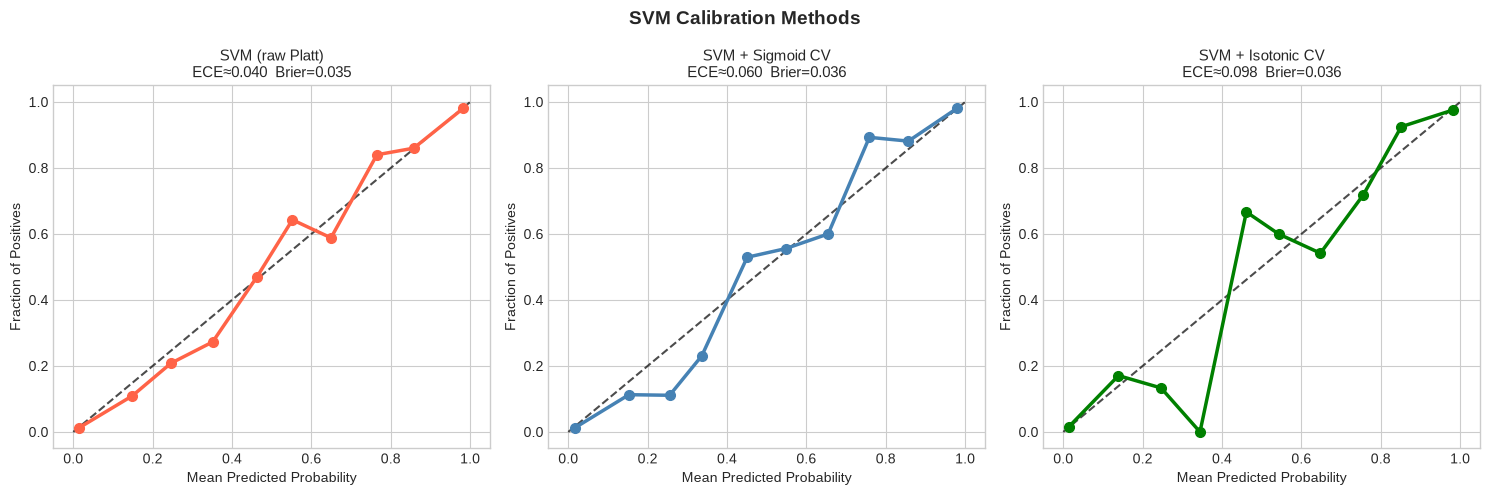

In [7]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# SVM is typically poorly calibrated out of the box
base_svm = SVC(random_state=42)

# CalibratedClassifierCV with cross-validation (no data waste)
cal_svm_sigmoid = CalibratedClassifierCV(base_svm, method='sigmoid', cv=5)
cal_svm_isotonic = CalibratedClassifierCV(SVC(random_state=42), method='isotonic', cv=5)

cal_svm_sigmoid.fit(X_train, y_train)
cal_svm_isotonic.fit(X_train, y_train)

p_sigmoid = cal_svm_sigmoid.predict_proba(X_test)[:, 1]
p_isotonic = cal_svm_isotonic.predict_proba(X_test)[:, 1]

# Also uncalibrated (use SVC probability=True for comparison)
svm_prob = SVC(probability=True, random_state=42)
svm_prob.fit(X_train, y_train)
p_raw = svm_prob.predict_proba(X_test)[:, 1]

# Compare using sklearn's calibration_curve
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['SVM (raw Platt)', 'SVM + Sigmoid CV', 'SVM + Isotonic CV']
probs_list = [p_raw, p_sigmoid, p_isotonic]
colors = ['tomato', 'steelblue', 'green']

for ax, title, probs, color in zip(axes, titles, probs_list, colors):
    frac_pos, mean_pred = calibration_curve(y_test, probs, n_bins=10)
    ece = np.mean(np.abs(frac_pos - mean_pred))
    bs = brier_score_loss(y_test, probs)
    ax.plot([0,1],[0,1],'k--', alpha=0.7)
    ax.plot(mean_pred, frac_pos, 'o-', color=color, linewidth=2.5, markersize=7)
    ax.set_title(f'{title}\nECE≈{ece:.3f}  Brier={bs:.3f}', fontsize=11)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')

plt.suptitle('SVM Calibration Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_calibration.png', dpi=80, bbox_inches='tight')
plt.show()

---
## 6. Calibration Metrics Summary

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Brier Score** | $\frac{1}{n}\sum(y_i - \hat{p}_i)^2$ | Lower is better; 0=perfect, 0.25=random |
| **ECE** | $\sum_b \frac{|B_b|}{n}|\text{acc}(B_b) - \text{conf}(B_b)|$ | Weighted mean calibration error; lower is better |
| **MCE** | $\max_b |\text{acc}(B_b) - \text{conf}(B_b)|$ | Worst-case calibration error |
| **NLL / Log-Loss** | $-\sum_i y_i\log \hat{p}_i + (1-y_i)\log(1-\hat{p}_i)$ | Strictly proper scoring rule |
| **Reliability** | Visual calibration curve | Should lie on diagonal |

In [8]:
# Summary table
from sklearn.metrics import brier_score_loss, log_loss

configs = [
    ('Logistic Regression', results['Logistic Regression']),
    ('GBM (raw)', raw_stats),
    ('GBM + Platt', platt_stats),
    ('GBM + Isotonic', iso_stats),
]

print(f'{"Model":<25} {"ECE":>8} {"MCE":>8} {"Brier":>8}')
print('-' * 55)
for name, stats in configs:
    print(f'{name:<25} {stats["ece"]:>8.4f} {stats["mce"]:>8.4f} {stats["brier"]:>8.4f}')

Model                          ECE      MCE    Brier
-------------------------------------------------------
Logistic Regression         0.0253   0.1189   0.1210
GBM (raw)                   0.0639   0.1799   0.0702
GBM + Platt                 0.0395   0.1436   0.0665
GBM + Isotonic              0.0239   0.5149   0.0665


---
## Additional Learning Resources

| Resource | Type | Description |
|----------|------|-------------|
| **Guo et al. (2017) — On Calibration of Modern Neural Networks** | Paper | Original temperature scaling paper |
| **Platt (1999) — Probabilistic Outputs for SVM** | Paper | Original Platt scaling paper |
| **sklearn Calibration Docs** | Docs | [scikit-learn.org/stable/modules/calibration](https://scikit-learn.org/stable/modules/calibration.html) |
| **Niculescu-Mizil & Caruana (2005)** | Paper | When to use Platt vs Isotonic |
| **The Brier Score** | Wikipedia | [Brier score](https://en.wikipedia.org/wiki/Brier_score) |
| **Practical Calibration (fast.ai blog)** | Blog | Discussion of calibration in practice |